# Module 3: Overview of Generative AI (الذكاء الاصطناعي التوليدي)

## Learning Objectives
By the end of this module, you will be able to:
- Understand what makes AI "generative" vs. discriminative
- Recognize different types of generative models and their applications
- Understand latent space and representation learning
- See how probabilistic sampling creates new content

---

## 1. What is Generative AI (الذكاء الاصطناعي التوليدي)?

### Discriminative vs Generative Models

**Discriminative Models** (what we've seen so far):
- Learn the **boundary** between classes
- Answer: "What is this?" (Classification (التصنيف))
- Example: "This image is a cat" (probability of label given input)
- Mathematically: Model P(y|x) - probability of label given input

**Generative Models** (focus of this course):
- Learn the **data distribution** itself
- Answer: "What does this look like?" (generation)
- Example: "Generate a new image that looks like a cat"
- Mathematically: Model P(x) - probability distribution of the data

```
Discriminative:  Image → [Model] → "Cat" (classify existing data)
Generative:      "Cat" → [Model] → New Image (create new data)
```

### Applications of Generative AI (الذكاء الاصطناعي التوليدي)

| Domain | Examples |
|--------|----------|
| **Text** | ChatGPT, Claude, writing assistants, code generation |
| **Images** | DALL-E, Midjourney, Stable Diffusion, image editing |
| **Audio** | Music generation, voice synthesis, audio editing |
| **Video** | Sora, video synthesis, deepfakes |
| **Code** | GitHub Copilot, code completion, bug fixing |
| **3D** | NeRF, 3D model generation, game assets |
| **Science** | Drug discovery, protein folding, material design |

---

## 2. Probabilistic Foundations

At its core, Generative AI (الذكاء الاصطناعي التوليدي) creates new content through **probabilistic sampling** from learned distributions.

### Simple Example: Generating Text

Language models learn the probability of words given context:

```
"The cat sat on the ___"

P(mat | context) = 0.35
P(floor | context) = 0.25  
P(chair | context) = 0.20
P(roof | context) = 0.10
P(moon | context) = 0.01
...
```

The model **samples** from this distribution, potentially picking "mat", "floor", or even "moon" (with lower probability).

### Hands-On Demo: Temperature-Based Sampling

**What to Expect:**
In the following demo, you will see how **temperature** affects word generation in language models.

**Learning Objectives:**
- Understand how temperature controls the randomness of generated output
- Observe the difference between low temperature (focused, predictable) and high temperature (diverse, creative)
- See how the same probability distribution produces different results at different temperatures

**What to Watch For:**
- At **low temperature (0.3)**: The model almost always picks the highest-probability words ("mat", "floor")
- At **temperature 1.0**: The original probabilities are used as-is
- At **high temperature (2.0)**: Even unlikely words ("moon", "keyboard") have a better chance of being selected

In [ ]:
!uv pip install -q numpy matplotlib scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Demo: Probabilistic Sampling for Word Generation
def sample_next_word(probabilities, words, temperature=1.0):
    """
    Sample a word based on probability distribution.
    Temperature controls randomness:
    - Low temp (0.1) = More deterministic, picks likely words
    - High temp (2.0) = More random, more creative
    """
    # Apply temperature scaling
    scaled_probs = np.array(probabilities) ** (1/temperature)
    scaled_probs = scaled_probs / scaled_probs.sum()  # Renormalize

    return str(np.random.choice(words, p=scaled_probs))

# Word probabilities for "The cat sat on the ___"
words = ['mat', 'floor', 'chair', 'roof', 'moon', 'keyboard']
probs = [0.35, 0.25, 0.20, 0.10, 0.05, 0.05]

# Sample at different temperatures
print("Prompt: 'The cat sat on the ___'\n")

for temp in [0.3, 1.0, 2.0]:
    samples = [sample_next_word(probs, words, temp) for _ in range(10)]
    print(f"Temperature {temp}: {samples}")

print("\n💡 Lower temperature = more predictable (mat, floor)")
print("   Higher temperature = more creative/random (moon, keyboard)")

Prompt: 'The cat sat on the ___'

Temperature 0.3: ['mat', 'chair', 'floor', 'mat', 'mat', 'mat', 'mat', 'floor', 'mat', 'floor']
Temperature 1.0: ['mat', 'keyboard', 'roof', 'mat', 'mat', 'mat', 'mat', 'floor', 'floor', 'mat']
Temperature 2.0: ['chair', 'mat', 'floor', 'floor', 'floor', 'roof', 'mat', 'chair', 'chair', 'mat']

💡 Lower temperature = more predictable (mat, floor)
   Higher temperature = more creative/random (moon, keyboard)


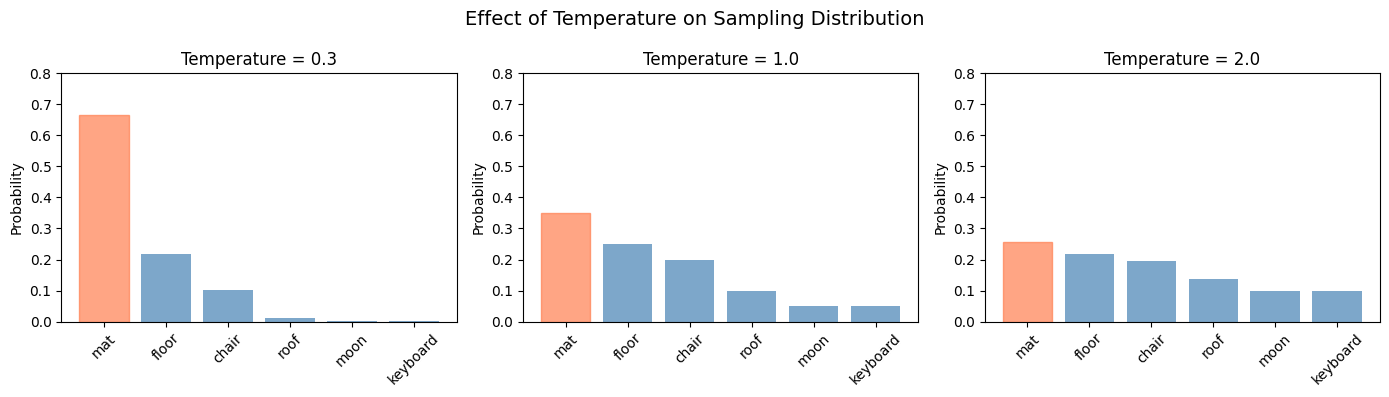

In [2]:
# Visualize how temperature affects probability distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
temps = [0.3, 1.0, 2.0]

for ax, temp in zip(axes, temps):
    scaled = np.array(probs) ** (1/temp)
    scaled = scaled / scaled.sum()
    
    bars = ax.bar(words, scaled, color='steelblue', alpha=0.7)
    ax.set_title(f'Temperature = {temp}', fontsize=12)
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 0.8)
    ax.tick_params(axis='x', rotation=45)
    
    # Highlight the max
    max_idx = np.argmax(scaled)
    bars[max_idx].set_color('coral')

plt.suptitle('Effect of Temperature on Sampling Distribution', fontsize=14)
plt.tight_layout()
plt.show()

---
### 🔍 Making Sense of the Charts

Generative models don't just pick one word — they calculate a **probability distribution** across thousands of possible next words. Temperature reshapes that distribution before the final roll of the dice.

Look at the three charts above:

1. **Left (Temperature = 0.3): The "Safe & Boring" Setting**
   - The most likely word ("mat") had its probability dramatically *amplified* (the tall orange bar).
   - Less likely words ("roof", "moon") were crushed down to nearly 0.
   - **Result:** The model almost always picks the top choice. Use low temperatures (0.0 – 0.3) for coding, data extraction, and factual answers where you want repeatability.

2. **Middle (Temperature = 1.0): The "Default" Setting**
   - This represents the model's raw, unaltered confidence. 
   - It usually picks the top word, but occasionally throws in a curveball.
   - **Result:** Good balance. Use for conversational bots, general writing, and standard tasks.

3. **Right (Temperature = 2.0): The "Hallucination / Chaos" Setting**
   - The probabilities have been flattened. Everything is now equally likely. Note how the "mat" bar shrank and the "keyboard" bar grew.
   - **Result:** The model ignores its training data and picks words almost at random. It will generate gibberish or severe hallucinations. Use high temperatures (0.7 – 1.0) for creative brainstorming or poetry, but rarely go above 1.0 in production unless you want chaos.
   
> **Note:** The exact maximum temperature varies by API. OpenAI allows up to 2.0, while Anthropic allows up to 1.0. The concept remains exactly the same: low = focused, high = flat.


---

## 3. Demo: Generating Synthetic Data

Before generating complex content like images or text, let's understand the core principle: **learning a distribution and sampling from it**.

### Hands-On Demo: Learning a Distribution and Generating New Samples

**What to Expect:**
This demo simulates how generative models work by:
1. Creating "real" customer data with two clusters (budget and premium customers)
2. Using a Gaussian Mixture Model (GMM) to **learn** the underlying distribution
3. **Generating new synthetic data** that follows the same patterns

**Learning Objectives:**
- Understand the core principle of Generative AI (الذكاء الاصطناعي التوليدي): learning distributions and sampling from them
- See how a model can capture the "essence" of data without memorizing specific examples
- Observe that generated data maintains the same statistical properties as real data

**What to Watch For:**
- The left plot shows the **original data** with two distinct customer clusters
- The right plot shows **generated data** that looks similar but contains entirely new points
- Notice how the model learned to generate points in the same regions/patterns as the real data

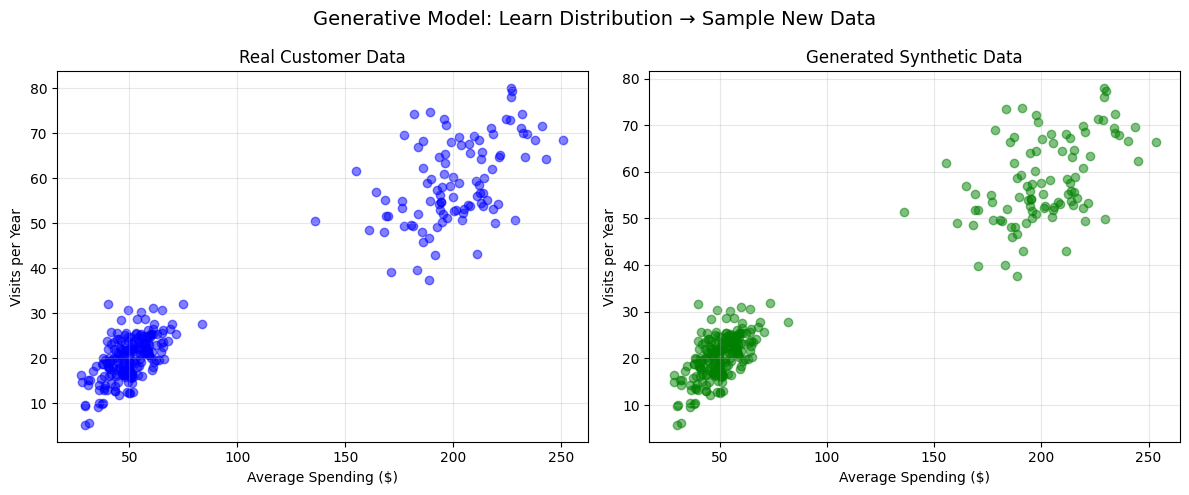

💡 Key insight: The model learned the DISTRIBUTION of real data,
   then generated NEW points that follow the same patterns!


In [3]:
# Demo: Generate synthetic 2D data that matches a distribution

# Step 1: Create some "real" data (let's say customer spending patterns)
np.random.seed(42)

# Two clusters: budget customers and premium customers
budget_customers = np.random.multivariate_normal(
    mean=[50, 20],  # avg spending $50, 20 visits/year
    cov=[[100, 30], [30, 25]],
    size=200
)

premium_customers = np.random.multivariate_normal(
    mean=[200, 60],  # avg spending $200, 60 visits/year
    cov=[[400, 100], [100, 100]],
    size=100
)

real_data = np.vstack([budget_customers, premium_customers])

# Step 2: Simple generative approach - fit Gaussian Mixture Model
from sklearn.mixture import GaussianMixture

# "Learn" the distribution
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(real_data)

# Step 3: Generate NEW synthetic data by sampling from learned distribution
synthetic_data, _ = gmm.sample(300)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_data[:, 0], real_data[:, 1], alpha=0.5, c='blue')
axes[0].set_xlabel('Average Spending ($)')
axes[0].set_ylabel('Visits per Year')
axes[0].set_title('Real Customer Data', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(synthetic_data[:, 0], synthetic_data[:, 1], alpha=0.5, c='green')
axes[1].set_xlabel('Average Spending ($)')
axes[1].set_ylabel('Visits per Year')
axes[1].set_title('Generated Synthetic Data', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Generative Model: Learn Distribution → Sample New Data', fontsize=14)
plt.tight_layout()
plt.show()

print("💡 Key insight: The model learned the DISTRIBUTION of real data,")
print("   then generated NEW points that follow the same patterns!")

---

## 4. Types of Generative Models

### Evolution of Generative Models

```
2013-2014: Autoencoders & VAEs              (Representation learning)
    │
    ▼
2014: GANs (Generative Adversarial Networks) (Realistic images via adversarial training)
    │
    ▼
2017: Transformers                           (Attention mechanism — revolutionized sequences)
    │
    ▼
2018-2020: GPT, BERT                         (Language understanding and generation at scale)
    │
    ▼
2020-2022: Diffusion Models                  (DALL-E 2, Stable Diffusion — high-quality images)
    │
    ▼
2022: DiT (Diffusion Transformers)           (Transformer backbone replaces U-Net in diffusion)
    │
    ▼
2022-2023: Flow Matching / Rectified Flows   (Faster, straighter diffusion paths — SD3, FLUX)
    │
    ▼
2023: Consistency Models                     (Single-step generation via distillation)
    │
    ▼
2023-2024: Large Multimodal Models           (GPT-4V, Gemini, Claude — text + image + audio)
    │
    ▼
2024-2025: Video & 3D Generation             (Sora, Wan, Kling — full video from text)
```

### Key Architectures

| Model Type | Key Idea | Best For |
|------------|----------|----------|
| **Autoencoders** | Compress → Reconstruct | Learning representations |
| **VAEs** | Autoencoders + probabilistic latent space | Smooth generation, image encoders |
| **GANs** | Generator vs Discriminator adversarial game | Fast realistic image synthesis |
| **Transformers** | Self-attention over sequences | Text, long-range dependencies |
| **Diffusion** | Denoise random noise step by step | High-quality controllable images |
| **Flow Matching** | Learn straight paths from noise to data | Faster training and inference than DDPM |

### Model Intuitions

**GANs (Generative Adversarial Networks):** Two Neural Networks (الشبكات العصبية) compete: a *generator* tries to produce realistic fakes, and a *discriminator* tries to tell them apart from real data. Through this adversarial game the generator learns to produce increasingly convincing outputs. GANs excel at sharp, photorealistic images but are notoriously hard to train — if the two networks fall out of balance the generator can suffer *mode collapse*, producing only a narrow variety of outputs. Diffusion models have largely replaced GANs for image synthesis, though GAN ideas still appear in evaluation metrics and some video models.

**Transformers:** Introduced in the 2017 paper "Attention Is All You Need," Transformers replaced recurrent architectures (RNNs, LSTMs) with *self-attention* — a mechanism that lets every token in a sequence attend to every other token simultaneously. This makes training fully parallelizable and captures long-range dependencies that sequential models struggled with. The Transformer backbone underpins virtually every modern large language model (GPT-4, Claude, Gemini), as well as vision models (ViT) and multimodal systems. You'll study it in depth in Module 05.

**Diffusion Models:** Learn to generate by reversing a gradual noising process. During training, random Gaussian noise is added to an image over many small steps until it becomes pure noise; a neural network learns to *undo* each step. At inference, you start from pure noise and iteratively denoise it into a coherent image — guided by a text prompt, an edge map, or any other conditioning signal. The key insight is that each small denoising step is a tractable learning problem, and chaining many steps produces high-quality, diverse outputs. Stable Diffusion, DALL-E 2, and Imagen all use this principle. Module 03's third notebook covers diffusion in detail.

---

## 5. Latent Space: The Secret Sauce

### What is Latent Space?

A **latent space** is a compressed representation of data where similar items are close together.

```
High-Dimensional Data              Latent Space (Low-Dimensional)
    ┌─────────────┐                      ┌─────────────┐
    │ Image:      │                      │      •cat   │
    │ 28x28=784   │  ────Encode────►     │   •dog      │
    │ dimensions  │                      │      •tiger │
    └─────────────┘                      │  (2-10 dim) │
                                         └─────────────┘
```

### Why it Matters for Generation

1. **Compression:** Complex data is compressed to essential features
2. **Interpolation:** Moving in latent space creates smooth transitions
3. **Manipulation:** Arithmetic in latent space changes attributes
4. **Sampling:** Random points in latent space decode to new content

**Famous Example:** Word2Vec showed that:
```
vector("King") - vector("Man") + vector("Woman") ≈ vector("Queen")
```

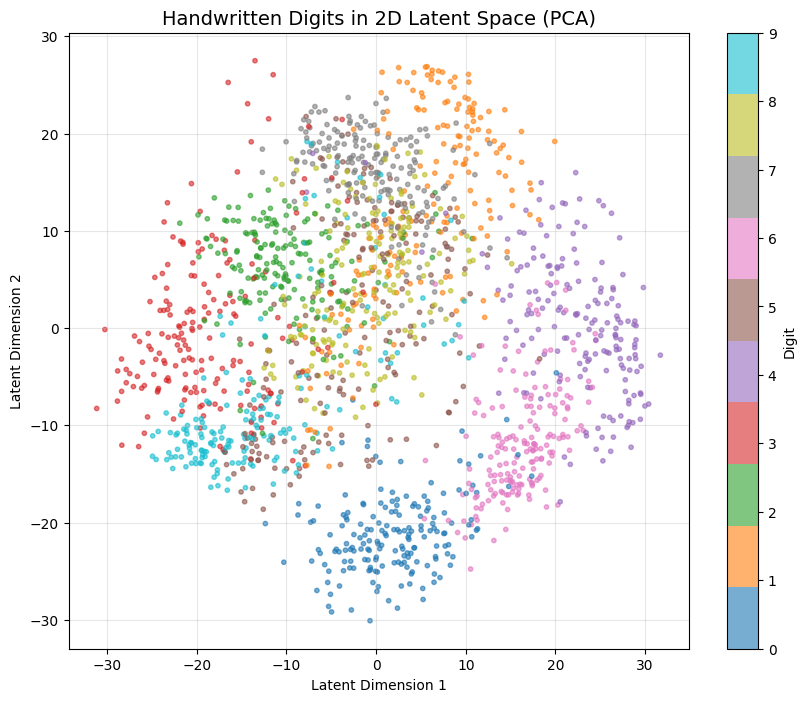

💡 Notice: Similar digits cluster together in latent space!
   The model learned that certain features matter for distinguishing digits.


In [4]:
# Demo: Visualizing Latent Space with PCA
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
import warnings
warnings.filterwarnings('ignore')

# Load digits dataset — 8x8 handwritten digits, no download required
digits = load_digits()
X_subset = digits.data[:2000]    # Already flat: shape (n_samples, 64)
y_subset = digits.target[:2000]

# Compress 64 dimensions → 2 dimensions (latent space approximation)
pca = PCA(n_components=2)
X_latent = pca.fit_transform(X_subset)

# Visualize
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_latent[:, 0], X_latent[:, 1],
                      c=y_subset, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, label='Digit')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Handwritten Digits in 2D Latent Space (PCA)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("💡 Notice: Similar digits cluster together in latent space!")
print("   The model learned that certain features matter for distinguishing digits.")

---
### 🔍 Making Sense of the Latent Space Plot

What are you actually looking at in this scatter plot? 

Imagine you have a dataset of human faces. Each image is composed of thousands of pixels (features). It's impossible for humans to visualize a 10,000-dimensional space. 

**Latent space** is a compressed, "hidden" representation of that complex data. The plot above uses a technique called PCA (Principal Component Analysis) to squash those high-dimensional features down to just 2 dimensions (X and Y) so we can see them.

**What this shows us:**
1. **Meaning is captured by position:** Notice how similar items group together into distinct clusters (e.g., the different colored points). In latent space, physical distance equals semantic similarity. Two dots close to each other represent data points that are conceptually similar.
2. **The empty space has meaning:** The empty gaps between the clusters are what generative models use! To create *new* data, a model can simply pick a random coordinate in the empty space between known clusters, and "decode" that coordinate back into the original format (like an image or text). 
3. **Smooth transitions (Interpolation):** If you draw a line from cluster A to cluster B, and decode the points along that line, you would get a smooth, logical transition blending the features of A and B.

> **Key Takeaway:** Generative AI (الذكاء الاصطناعي التوليدي) doesn't memorize images or text directly. It learns this map (the latent space). Generating new content simply means exploring new coordinates on the map.


---

## 6. Autoencoder Architecture

An **autoencoder** is a neural network that learns to compress and reconstruct data.

```
Input ──► [Encoder] ──► Latent Code ──► [Decoder] ──► Reconstruction
  x            ↓            z              ↓              x'
             Compress                   Decompress
           (784→32)                     (32→784)
```

### Why Train to Reconstruct?

- Forces the network to learn **meaningful features**
- The latent code must capture the "essence" of the input
- Forms the basis for more powerful models like VAEs

### Loss Function

```
Reconstruction Loss = ||x - x'||² (Mean Squared Error)
```

The network learns to minimize the difference between input and output.

> 💡 **Autoencoder Architecture (Conceptual Summary)**
>
> ```
> Input x ──► [Encoder] ──► Latent z ──► [Decoder] ──► Reconstruction x'
>   (784)      Compress       (32)        Decompress       (784)
> ```
>
> - **Encoder**: Dense layers that progressively compress (784 → 256 → 128 → 32)
> - **Latent code**: The bottleneck — must encode everything essential
> - **Decoder**: Dense layers that reconstruct from the code (32 → 128 → 256 → 784)
> - **Loss**: Mean Squared Error between input and reconstruction
>
> **You'll implement this from scratch in `02_autoencoders.ipynb`.**
> That notebook walks through every layer, trains on MNIST, and shows reconstructions.

> ℹ️ *Training and reconstruction visualization are covered in detail in `02_autoencoders.ipynb`. Head there for the full hands-on lab.*

### Why Can't a Standard Autoencoder Generate?

If you sample a **random point** in the latent space of a standard autoencoder and decode it, the result is garbage. Why?

Because the encoder learned to map each training input to a *specific point*, not a region. Random points land in unmapped territory — the decoder has never seen them.

**The solution: Variational Autoencoders (VAEs)** — covered in `02_autoencoders.ipynb`.

Instead of mapping inputs to points, VAEs map inputs to *distributions* (Gaussian regions). This forces the latent space to be smooth and continuous: any point you sample decodes to something meaningful.

---

## 7. Connection to LLMs and Modern GenAI

The concepts we've learned are foundational to modern LLMs:

| Concept | In Autoencoders | In LLMs |
|---------|-----------------|----------|
| **Latent representation** | Compressed image code | Token embeddings |
| **Probabilistic sampling** | Sample from latent space | Sample next token |
| **Temperature** | Controls randomness | Controls creativity |
| **Reconstruction** | Reconstruct images | Predict next tokens |
| **Learned features** | Edge, shape detectors | Word relationships, context |

### The Path Forward

```
This Module:    Autoencoders, VAEs (learn representations)
     ↓
Module 4:       NLP basics (text as data)
     ↓
Module 5:       LLMs (Transformers, GPT, BERT)
     ↓
Module 6-9:     Apply to real tasks
```

---

## 📝 Student Activities

### Activity 1: Experiment with Temperature
Modify the word sampling code to:
1. Add more words to the vocabulary
2. Try extreme temperatures (0.1 and 5.0)
3. Observe how the distribution changes

### Activity 2: Modify the Autoencoder
1. Try different latent dimensions (2, 8, 64, 128)
2. How does reconstruction quality change?
3. What's the minimum latent dim for acceptable reconstructions?

### Activity 3: Explore Latent Space
1. Encode two different digits
2. Interpolate between their latent representations
3. Decode the intermediate points

Temperature 0.1: ['mat', 'mat', 'mat', 'mat', 'mat', 'mat', 'mat', 'mat', 'mat', 'mat']
Temperature 5.0: ['moon', 'chair', 'roof', 'table', 'mat', 'moon', 'roof', 'moon', 'mat', 'bed']


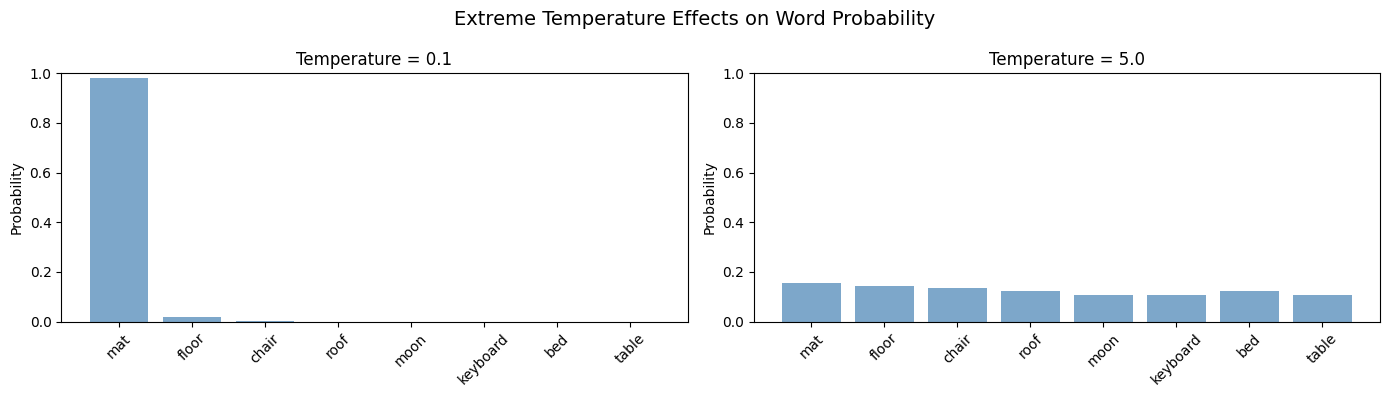

In [5]:
# ✏️ Activity 1: Experiment with Temperature
# Starter code — modify freely!

# 1. Extend the vocabulary
words_extended = ['mat', 'floor', 'chair', 'roof', 'moon', 'keyboard', 'bed', 'table']
probs_extended = [0.30, 0.20, 0.15, 0.10, 0.05, 0.05, 0.10, 0.05]
assert abs(sum(probs_extended) - 1.0) < 1e-9, "Probabilities must sum to 1.0"

# 2. Try extreme temperatures
for temp in [0.1, 5.0]:
    samples = [sample_next_word(probs_extended, words_extended, temp) for _ in range(10)]
    print(f"Temperature {temp}: {samples}")

# 3. Visualize the distribution shift at extreme temperatures
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, temp in zip(axes, [0.1, 5.0]):
    scaled = np.array(probs_extended) ** (1 / temp)
    scaled = scaled / scaled.sum()
    ax.bar(words_extended, scaled, color='steelblue', alpha=0.7)
    ax.set_title(f'Temperature = {temp}', fontsize=12)
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Extreme Temperature Effects on Word Probability', fontsize=14)
plt.tight_layout()
plt.show()

# 💡 Challenge: what happens at temperature → 0? At temperature → ∞?

### 🔬 Activity 3: Latent Space Interpolation

**Concept:** If the latent space is smooth, you can interpolate between two encoded points and decode the intermediate vectors. The outputs should form a gradual transition.

```python
z_0 = encoder(image_of_0)
z_1 = encoder(image_of_1)

for alpha in [0, 0.1, 0.2, ..., 1.0]:
    z_interp = (1 - alpha) * z_0 + alpha * z_1
    output = decoder(z_interp)   # Gradual 0 → 1 transition
```

**Try this in `02_autoencoders.ipynb`** after completing the VAE section. The VAE's structured latent space ensures that intermediate decoded points produce meaningful transitions — unlike a standard autoencoder where interpolations land in unmapped territory.

---

## Key Takeaways

1. **Generative AI (الذكاء الاصطناعي التوليدي)** creates new content by learning data distributions and sampling from them
2. **Temperature** controls the randomness/creativity of generation
3. **Latent space** is a compressed representation where similar things are near each other
4. **Autoencoders** learn to compress and reconstruct data (encode → latent → decode)
5. **VAEs** add a probabilistic latent space that makes smooth, sampleable generation possible
6. **Diffusion models** iteratively denoise random noise — the current state of the art for images
7. These foundations lead directly to **Transformers, LLMs, and every modern GenAI system**

---

### Continue with:
- **02_autoencoders.ipynb** — Build Autoencoders and VAEs from scratch on MNIST
- **03_diffusion_models.ipynb** — Text-to-image generation with Stable Diffusion

### Next Module: Module 04 — NLP: Understanding Language as Data →

# 🤖 Generative AI (الذكاء الاصطناعي التوليدي) and Large Language Models
**Day 4 — Modern ML & the Bigger Picture**

---

Everything you've learned this week describes *discriminative* models — models that learn to predict a label or value given an input. Neural Networks (الشبكات العصبية) took this same idea and scaled it.

Generative AI (الذكاء الاصطناعي التوليدي) takes one more conceptual step: instead of predicting a label, the model learns the **probability distribution of the data itself** — well enough to **generate** new examples.

In this notebook:
- Understand the conceptual difference: discriminative vs. generative
- See how temperature controls generation creativity
- Understand how LLMs (like GPT) are trained
- Run a simple prompt engineering demo with a real LLM API (optional)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
np.random.seed(42)
print("Ready ✓")

Ready ✓


## Discriminative vs. Generative

| | Discriminative | Generative |
|---|---|---|
| **Question** | What class is this input? | What does this data distribution look like? |
| **Learns** | P(y \| x) — probability of label given input | P(x) — probability of the data itself |
| **Examples** | Logistic Regression, Decision Trees (أشجار القرار), CNNs | GPT, Stable Diffusion, VAEs |
| **Output** | A label or number | New text, images, audio |

The key insight: to *generate* something new, the model must have learned a rich internal representation of the data's structure.

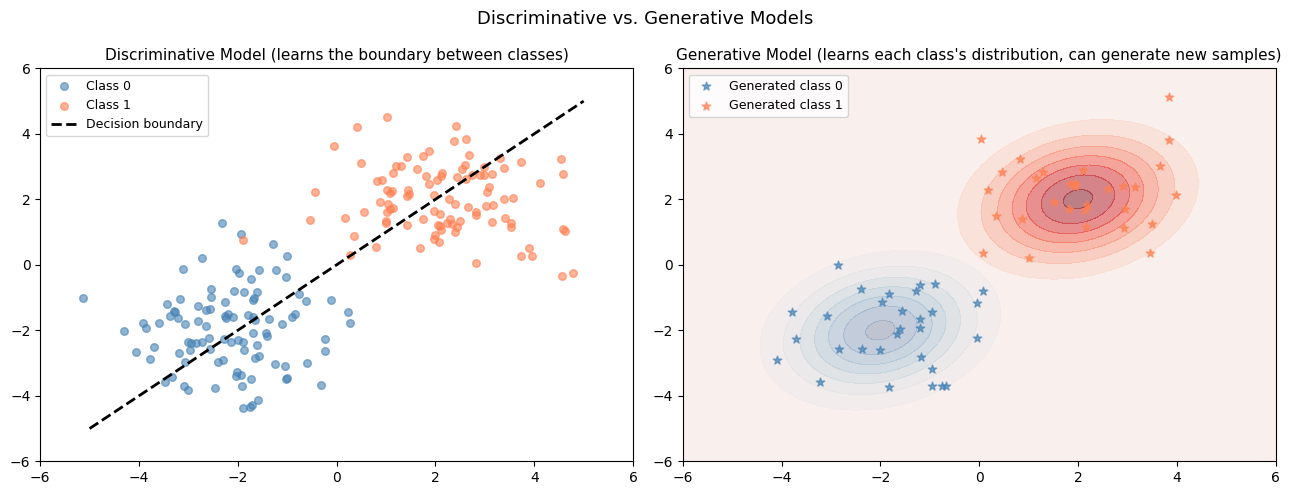

In [3]:
# Visualize: discriminative boundary vs generative distribution
from sklearn.datasets import make_blobs
from scipy.stats import multivariate_normal

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Generate two-class data
X2, y2 = make_blobs(n_samples=200, centers=[[-2, -2], [2, 2]], cluster_std=1.2, random_state=42)

# Left: Discriminative — learns the boundary
colors = ["steelblue", "coral"]
for cls in range(2):
    mask = y2 == cls
    axes[0].scatter(X2[mask, 0], X2[mask, 1], c=colors[cls], s=30, alpha=0.6, label=f"Class {cls}")
axes[0].plot([-5, 5], [-5, 5], "k--", linewidth=2, label="Decision boundary")
axes[0].set_title("Discriminative Model (learns the boundary between classes)", fontsize=11)
axes[0].legend(fontsize=9); axes[0].set_xlim(-6, 6); axes[0].set_ylim(-6, 6)

# Right: Generative — models each class's distribution
xx, yy = np.meshgrid(np.linspace(-6, 6, 100), np.linspace(-6, 6, 100))
pos = np.dstack([xx, yy])
for i, (mean, color, cmap) in enumerate([
    ([-2, -2], "steelblue", "Blues"), ([2, 2], "coral", "Reds")
]):
    rv = multivariate_normal(mean=mean, cov=[[1.5, 0.3], [0.3, 1.5]])
    Z = rv.pdf(pos)
    axes[1].contourf(xx, yy, Z, levels=8, cmap=cmap, alpha=0.5)
    # Show generated new samples
    new_samples = rv.rvs(size=30)
    axes[1].scatter(new_samples[:, 0], new_samples[:, 1], c=color, s=40, alpha=0.7,
                    marker="*", zorder=5, label=f"Generated class {i}")

axes[1].set_title("Generative Model (learns each class's distribution, can generate new samples)", fontsize=11)
axes[1].legend(fontsize=9); axes[1].set_xlim(-6, 6); axes[1].set_ylim(-6, 6)

plt.suptitle("Discriminative vs. Generative Models", fontsize=13)
plt.tight_layout(); plt.show()

## How LLMs Are Trained: Self-Supervised Learning (التعلم الخاضع للإشراف) at Scale

Large Language Models (GPT, Claude, LLaMA, Gemini) are trained using **self-Supervised Learning (التعلم الخاضع للإشراف)** — specifically, **next-token prediction**:

1. Take a huge corpus of text (books, web pages, code — trillions of tokens)
2. For each piece of text: mask the next word
3. Train the model to predict the masked word
4. No human labels needed — the text itself provides the training signal

This is the same "self-supervised" category from Day 1's animation. The model sees billions of examples like:

```
"The cat sat on the [MASK]" → "mat"
"Paris is the capital of [MASK]" → "France"
"def function(x): return x [MASK]" → "*"
```

After seeing enough examples, the model builds a deep understanding of language, facts, and reasoning.

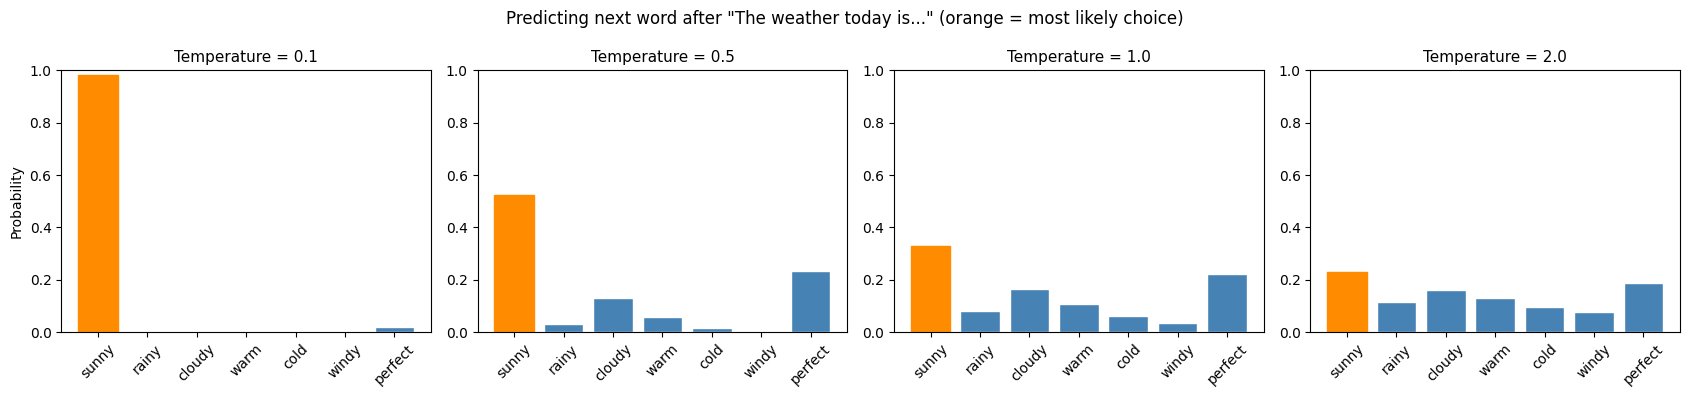

Low temperature (0.1): model almost always picks 'sunny' — predictable but repetitive
High temperature (2.0): probabilities flatten — more creative, but less coherent
Temperature = 1.0: default behavior, balanced creativity


In [5]:
# Simulate how temperature affects text generation
# This is a simplified demonstration of the sampling process

# Imagine the model is predicting the next word after "The weather today is"
word_candidates = ["sunny", "rainy", "cloudy", "warm", "cold", "windy", "perfect"]
logits = np.array([3.2, 1.8, 2.5, 2.1, 1.5, 1.0, 2.8])  # raw model scores

def softmax_with_temperature(logits, temperature):
    scaled = logits / temperature
    exp_scaled = np.exp(scaled - np.max(scaled))
    return exp_scaled / exp_scaled.sum()

temperatures = [0.1, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for ax, temp in zip(axes, temperatures):
    probs = softmax_with_temperature(logits, temp)
    bars = ax.bar(word_candidates, probs, color="steelblue", edgecolor="white")
    bars[np.argmax(logits)].set_color("darkorange")  # highlight top choice
    ax.set_title(f"Temperature = {temp}", fontsize=11)
    ax.set_ylabel("Probability" if temp == 0.1 else "")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle('Predicting next word after "The weather today is..." (orange = most likely choice)',
             fontsize=12)
plt.tight_layout(); plt.show()

print("Low temperature (0.1): model almost always picks 'sunny' — predictable but repetitive")
print("High temperature (2.0): probabilities flatten — more creative, but less coherent")
print("Temperature = 1.0: default behavior, balanced creativity")

## The Transformer Architecture (Conceptual Overview)

LLMs are built on the **Transformer** architecture (2017, "Attention is All You Need"). The key innovation is **self-attention**: instead of processing tokens one-by-one in sequence, every token can "attend" to every other token simultaneously.

This is why GPT can understand:
- "The bank by the river was flooded" (bank = financial? riverbank?)
- Context from 100 sentences ago
- Complex code structure across many lines

**The architecture at a glance:**

```
Input text → Tokenize → Embeddings → [Self-Attention + Feed-Forward] × N layers → Output distribution
```

Each `Self-Attention + Feed-Forward` block is called a **Transformer block** or **layer**. GPT-3 has 96 layers. Each layer has millions of parameters. All trained by minimizing next-token prediction loss.

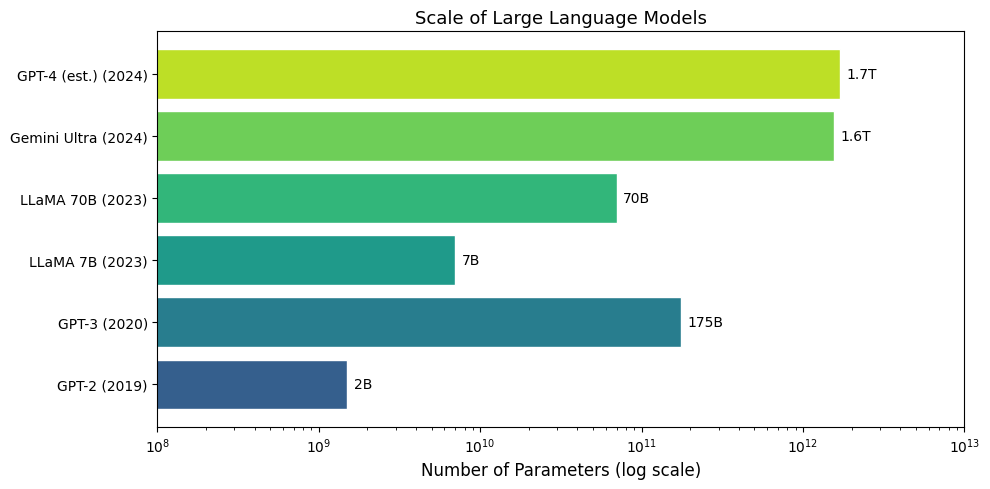

Remember: every single parameter was learned by gradient descent
minimizing next-token prediction loss. Same algorithm you saw in Day 1.


In [6]:
# Show the scale of modern LLMs
models = {
    "GPT-2 (2019)":           1.5e9,
    "GPT-3 (2020)":           175e9,
    "LLaMA 7B (2023)":        7e9,
    "LLaMA 70B (2023)":       70e9,
    "Gemini Ultra (2024)":    1.56e12,
    "GPT-4 (est.) (2024)":    1.7e12,
}

fig, ax = plt.subplots(figsize=(10, 5))
names = list(models.keys())
params = list(models.values())
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(names)))

bars = ax.barh(names, params, color=colors, edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Number of Parameters (log scale)", fontsize=12)
ax.set_title("Scale of Large Language Models", fontsize=13)

for bar, val in zip(bars, params):
    if val >= 1e12:
        label = f"{val/1e12:.1f}T"
    elif val >= 1e9:
        label = f"{val/1e9:.0f}B"
    else:
        label = f"{val/1e6:.0f}M"
    ax.text(val * 1.1, bar.get_y() + bar.get_height()/2,
            label, va="center", fontsize=10)

ax.set_xlim(1e8, 1e13)
plt.tight_layout(); plt.show()

print("Remember: every single parameter was learned by gradient descent")
print("minimizing next-token prediction loss. Same algorithm you saw in Day 1.")

## Live Demo — Prompt Engineering

If you have API access, run the cell below to experiment with a real LLM. Otherwise, read through it to understand what's happening under the hood.

In [7]:
# Optional: Live LLM demo (requires API key)
# Uncomment and add your key to try this live

# import os
# os.environ["ANTHROPIC_API_KEY"] = "your-key-here"   # or use OpenAI

# from anthropic import Anthropic
# client = Anthropic()

# prompts_to_try = [
#     "In one sentence, explain what machine learning is to a 10-year-old.",
#     "What is the difference between supervised and unsupervised learning?",
#     "Give me three real-world examples of regression problems.",
# ]

# for prompt in prompts_to_try:
#     response = client.messages.create(
#         model="claude-opus-4-6",
#         max_tokens=200,
#         messages=[{"role": "user", "content": prompt}]
#     )
#     print(f"Prompt: {prompt}")
#     print(f"Response: {response.content[0].text}")
#     print()

# ─── Without API access, observe these prompt engineering principles ───

principles = [
    ("Be specific",          "Bad:  'Explain ML'\n  Good: 'Explain supervised learning to a college student in 3 sentences'"),
    ("Give examples",        "Bad:  'Write a function'\n  Good: 'Write a Python function that takes a list of prices and returns the average. Example: [100, 200, 300] → 200.0'"),
    ("Specify format",       "Bad:  'List the steps'\n  Good: 'List the 5 steps of the ML workflow as a numbered list, one sentence each'"),
    ("Set context/persona",  "Bad:  'Help me debug'\n  Good: 'You are a senior data scientist. Review this code and identify why the model is overfitting: [code]'"),
    ("Chain of thought",     "Bad:  'Is this model good?'\n  Good: 'Step by step, evaluate this model. First, check the train/test split. Then, check the accuracy. Finally, recommend improvements.'"),
]

print("=" * 60)
print("PROMPT ENGINEERING PRINCIPLES")
print("=" * 60)
for principle, example in principles:
    print(f"\n{principle.upper()}")
    print(f"  {example}")

PROMPT ENGINEERING PRINCIPLES

BE SPECIFIC
  Bad:  'Explain ML'
  Good: 'Explain supervised learning to a college student in 3 sentences'

GIVE EXAMPLES
  Bad:  'Write a function'
  Good: 'Write a Python function that takes a list of prices and returns the average. Example: [100, 200, 300] → 200.0'

SPECIFY FORMAT
  Bad:  'List the steps'
  Good: 'List the 5 steps of the ML workflow as a numbered list, one sentence each'

SET CONTEXT/PERSONA
  Bad:  'Help me debug'
  Good: 'You are a senior data scientist. Review this code and identify why the model is overfitting: [code]'

CHAIN OF THOUGHT
  Bad:  'Is this model good?'
  Good: 'Step by step, evaluate this model. First, check the train/test split. Then, check the accuracy. Finally, recommend improvements.'


---

## Key Takeaways

- **Generative models** learn the data distribution itself — not just a boundary
- LLMs like GPT are trained via **self-supervised next-token prediction** — no human labels needed at scale
- **Temperature** controls creativity: low = deterministic, high = diverse
- The Transformer's **self-attention** lets every token influence every other token
- Despite the scale, the training algorithm is still gradient descent — exactly what you saw on Day 1

**The through-line of this whole course:**

> Linear Regression (الانحدار الخطي) learned 4 parameters from 300 houses.  
> GPT-3 learned 175 billion parameters from the entire internet.  
> The algorithm is the same. The scale is what changed.